## What is Fortune dataset? 
It's a dataset containing the top `1000` largest conpanies in the USA rancked on the basis of the `revenue`.
Also include `profits`, `employees`, `sector`, `location`, etc. 

In [7]:
# Importing all the necessary libraries that will be required for the assignment

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
# import os


## Framing it as a Business problem 

1. sector that generate the `most revenue and profit`
2. sate that have most of the companies 
3. what is the average profir margin in per sector 
4. company that has the biggest rank change 
5. Does the gender leading compaies matter in the profit 
6. No of employees affect the revenue ?
7. Newcomer and their revenue w.r.t establieshed company


## what to explore 
1. revenue and profit analysis (margin calculation , highest revenue and profir company, its distribution, etc)
2. Sector analysis (sector with most companies, profitable sector, etc)
3. outlier analysis acoross all the numeric column and understanig their important 
4. other factor like rank, gender of ceo, state of company i.e newcomer or not 

## ML model predict ?

The most common and natural prediction target is the `profitable` column. 
we can do that on the basis of the columns like `revenue sector employees rank leadership` 


The model for predicting the profitable or not is the `supervised model` as we know the target column to train on 
also the problem is the of `classification` because  the output is either Yes or No 


`we` can also predict the profit amount or somthing like rank and that would be `supervised regression problem`

In [ ]:
import pandas as pd

class FortuneDataset:
    
    def __init__(self):
        self.df = None          # will store the dataframe after load() is called
    
    
    # METHOD 1 — load()
    
    def load(self, path: str) -> None:
        try:
            self.df = pd.read_csv(path, na_values = '?')
            print(f"Dataset loaded successfully — {self.df.shape[0]} rows, {self.df.shape[1]} columns")
        except FileNotFoundError:
            print(f"Error: File not found at '{path}'. Please check the path.") # exception handeling 
    
    
    # METHOD 2 — describe()
    
    def describe(self) -> None:
        
        # shape
        print("Shape:")
        print(self.df.shape)
        
        # column dtypes
        print("\nColumn Data Types:")
        print(self.df.dtypes)
        
        # null counts
        print("\nNull Value Counts:")
        print(self.df.isnull().sum())
        
        # list comprehension — filter only numeric columns
        numeric_cols = [col for col in self.df.columns if self.df[col].dtype != 'object']
        print("\nNumeric Columns:")
        print(numeric_cols)
    
    
    # METHOD 3 — split()
    
    def split(self, test_size: float = 0.2) -> tuple:
        
        total_rows   = len(self.df)                        
        test_rows    = int(total_rows * test_size)         
        train_rows   = total_rows - test_rows             
        
        train = self.df.iloc[:train_rows]                  
        test  = self.df.iloc[train_rows:]                  
        
        print(f"Train size : {len(train)} rows")
        print(f"Test size  : {len(test)} rows")
        
        return train, test



 
dataset = FortuneDataset() # create the object

dataset.load('/home/sudarshan/Desktop/LeapFrog_60_day/College_KO_Training/fortune_1000 - fortune_1000.csv') # load the CSV

dataset.describe() # print summary



Dataset loaded successfully — 1000 rows, 18 columns
Shape:
(1000, 18)

Column Data Types:
company               object
rank                   int64
rank_change            int64
revenue              float64
profit               float64
num. of employees    float64
sector                object
city                  object
state                 object
newcomer              object
ceo_founder           object
ceo_woman             object
profitable            object
prev_rank            float64
CEO                   object
Website               object
Ticker                object
Market Cap            object
dtype: object

Null Value Counts:
company                0
rank                   0
rank_change            0
revenue                0
profit                 3
num. of employees      1
sector                 0
city                   0
state                  0
newcomer               0
ceo_founder            0
ceo_woman              0
profitable             0
prev_rank            531
CEO 

In [13]:
# making the copy of the dataset to avoid any changes to the original dataset
# This approach make the code more clean and no risk of altering the original dataset if needed in the future
fortune_df = dataset.df.copy()
fortune_df.head()

,company,rank,rank_change,revenue,profit,num. of employees,sector,city,state,newcomer,ceo_founder,ceo_woman,profitable,prev_rank,CEO,Website,Ticker,Market Cap
0,Walmart,1,0,572754.0,13673.0,2300000.0,Retailing,Bentonville,AR,no,no,no,yes,1.0,C. Douglas McMillon,https://www.stock.walmart.com,WMT,352037
1,Amazon,2,0,469822.0,33364.0,1608000.0,Retailing,Seattle,WA,no,no,no,yes,2.0,Andrew R. Jassy,www.amazon.com,AMZN,1202717
2,Apple,3,0,365817.0,94680.0,154000.0,Technology,Cupertino,CA,no,no,no,yes,3.0,Timothy D. Cook,www.apple.com,AAPL,2443962
3,CVS Health,4,0,292111.0,7910.0,258000.0,Health Care,Woonsocket,RI,no,no,yes,yes,4.0,Karen Lynch,https://www.cvshealth.com,CVS,125204
4,UnitedHealth Group,5,0,287597.0,17285.0,350000.0,Health Care,Minnetonka,MN,no,no,no,yes,5.0,Andrew P. Witty,www.unitedhealthgroup.com,UNH,500468


In [15]:
# Mean, standard deviation, and L2 norm of the 'revenue' column using NumPy functions
revenue_mean = np.mean(fortune_df['revenue'])
revenue_std = np.std(fortune_df['revenue'])
revenue_l2_norm = np.linalg.norm(fortune_df['revenue'])

print(f"revenue Mean: {revenue_mean}")
print(f"revenue Standard Deviation: {revenue_std}")
print(f"revenue L2 Norm: {revenue_l2_norm}") # L2 norm is the square root of the sum of squares of the values in the 'revenue' column. 

revenue Mean: 17986.8014
revenue Standard Deviation: 40792.869808843774
revenue L2 Norm: 1409816.744064391


                    std        std
                  ◄─────►    ◄─────►
    |─────────────|──────────|──────────|─────────────|
   low           mean-std   MEAN     mean+std         high
   
   For example 
    mean         =  300
    std          =  100

    mean - std   =  200   (one std BELOW mean)
    mean + std   =  400   (one std ABOVE mean)  ← we want companies ABOVE this

In [ ]:
# using the boolean masking to find the companies with profit reater than one standard deviation above the mean
profit_mean = np.mean(fortune_df['profit'])
profit_std = np.std(fortune_df['profit'])

# setting the one std above the mean 
threshold = round(profit_mean + profit_std, 2) 


high_profit_companies = fortune_df[fortune_df['profit'] > threshold] # applying the boolean masking as fortune_df["profit"] > threshold  
print(f"Companies with profit greater than one standard deviation above the mean (threshold: {threshold}):")
print(high_profit_companies[['company', 'profit']]) 

Companies with profit greater than one standard deviation above the mean (threshold: 8444.83):
                          company   profit
0                         Walmart  13673.0
1                          Amazon  33364.0
2                           Apple  94680.0
4              UnitedHealth Group  17285.0
5                     Exxon Mobil  23040.0
6              Berkshire Hathaway  89795.0
7                        Alphabet  76033.0
12                           AT&T  20081.0
13                      Microsoft  61271.0
15                        Chevron  15625.0
16                     Home Depot  16433.0
18             Marathon Petroleum   9738.0
21                     Ford Motor  17937.0
22         Verizon Communications  22065.0
23                 JPMorgan Chase  48334.0
24                 General Motors  10019.0
26                 Meta Platforms  39370.0
27                        Comcast  14159.0
32                     Fannie Mae  22176.0
33          United Parcel Service  12890.0
35

# Adding the Profit_margin column 

profit_margin = (profit / revenue) * 100 


In [ ]:
# dropping the nan value in the profit column to avoid any error in the calculation of profit margin
fortune_df = fortune_df.dropna(subset=['profit'])



In [34]:
fortune_df["profit_margin"] = (fortune_df["profit"] / fortune_df["revenue"] * 100).round(2) 
fortune_df.head()

/tmp/ipykernel_29758/1691533511.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fortune_df["profit_margin"] = (fortune_df["profit"] / fortune_df["revenue"] * 100).round(2)


,company,rank,rank_change,revenue,profit,num. of employees,sector,city,state,newcomer,ceo_founder,ceo_woman,profitable,prev_rank,CEO,Website,Ticker,Market Cap,profit_margin
0,Walmart,1,0,572754.0,13673.0,2300000.0,Retailing,Bentonville,AR,no,no,no,yes,1.0,C. Douglas McMillon,https://www.stock.walmart.com,WMT,352037,2.39
1,Amazon,2,0,469822.0,33364.0,1608000.0,Retailing,Seattle,WA,no,no,no,yes,2.0,Andrew R. Jassy,www.amazon.com,AMZN,1202717,7.10
2,Apple,3,0,365817.0,94680.0,154000.0,Technology,Cupertino,CA,no,no,no,yes,3.0,Timothy D. Cook,www.apple.com,AAPL,2443962,25.88
3,CVS Health,4,0,292111.0,7910.0,258000.0,Health Care,Woonsocket,RI,no,no,yes,yes,4.0,Karen Lynch,https://www.cvshealth.com,CVS,125204,2.71
4,UnitedHealth Group,5,0,287597.0,17285.0,350000.0,Health Care,Minnetonka,MN,no,no,no,yes,5.0,Andrew P. Witty,www.unitedhealthgroup.com,UNH,500468,6.01


In [35]:
# Groupby to find the average revenue, average profit_margin, and total empoyee count per sector 

sector_summary = fortune_df.groupby('sector').agg({
    'revenue': 'mean',
    'profit_margin': 'mean',
    'num. of employees': 'sum'
}).reset_index()
sector_summary 

,sector,revenue,profit_margin,num. of employees
0,Aerospace & Defense,19940.117647,6.571765,857200.0
1,Apparel,7332.068750,9.602500,313245.0
2,Business Services,7378.325000,11.113462,1521413.0
3,Chemicals,10268.158621,11.479310,519363.0
4,Energy,18977.192929,8.150404,874773.0
5,Engineering & Construction,7931.281250,7.530938,468877.0
6,Financials,17531.636747,17.953133,3695473.0
7,Food & Drug Stores,49665.166667,2.942222,1334835.0
8,"Food, Beverages & Tobacco",18162.961765,10.728235,1122281.0
9,Health Care,34912.179221,12.849091,3384082.0


In [36]:
# Use value_counts() on state to find the top 10 headquarter states and store the result as a new DataFrame.

top_headquarter = fortune_df['state'].value_counts().head(10).reset_index()

top_headquarter.columns = ['state', 'count'] # renaming the columns for better readability
print("Top 10 Headquarter States:")
print(top_headquarter)



Top 10 Headquarter States:
  state  count
0    CA    131
1    TX     97
2    NY     87
3    IL     62
4    OH     54
5    PA     45
6    FL     38
7    VA     34
8    GA     34
9    MA     33


## doing the visiulaization of the dataset so that we get the better understanding of the data 


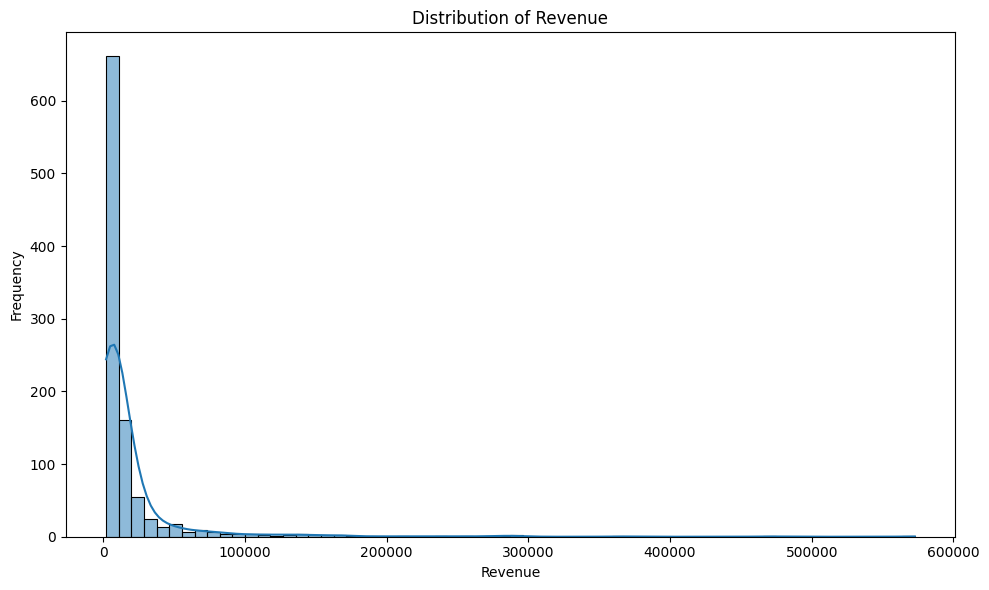

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(fortune_df['revenue'], kde=True, ax=ax)
ax.set_title('Distribution of Revenue')
ax.set_xlabel('Revenue')
ax.set_ylabel('Frequency')

plt.tight_layout() 
plt.show()


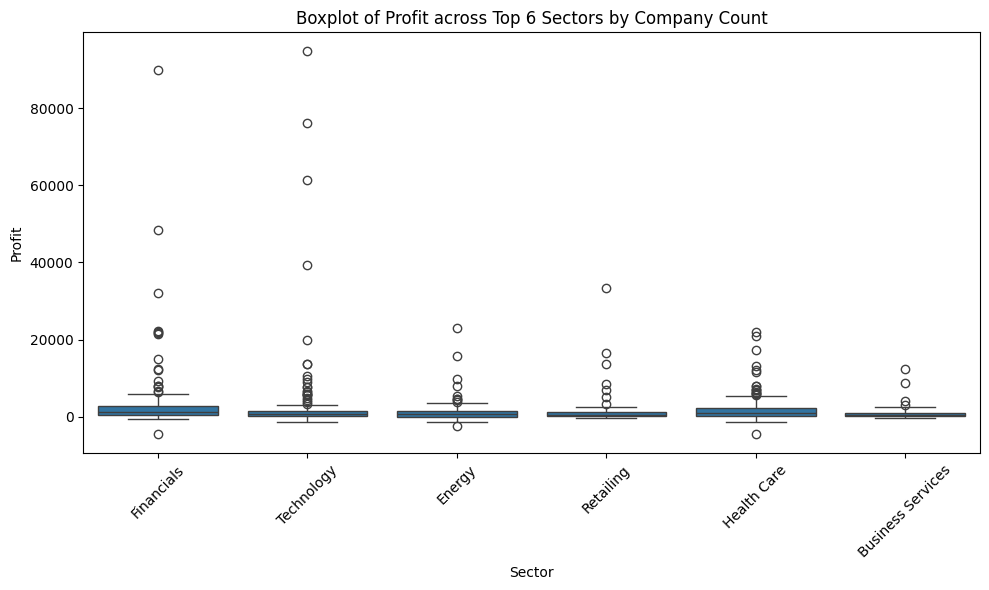

In [42]:
# a boxplot of profit across the top 6 sectors by company count 

fig, ax = plt.subplots(figsize=(10, 6))

top_6_sectors = fortune_df["sector"].value_counts().index[:6]  # top 6 sectors

sns.boxplot(x = fortune_df["sector"],         
            y = fortune_df["profit"], 
            ax = ax, 
            order = top_6_sectors)            

ax.set_title('Boxplot of Profit across Top 6 Sectors by Company Count')
ax.set_xlabel('Sector')
ax.set_ylabel('Profit')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


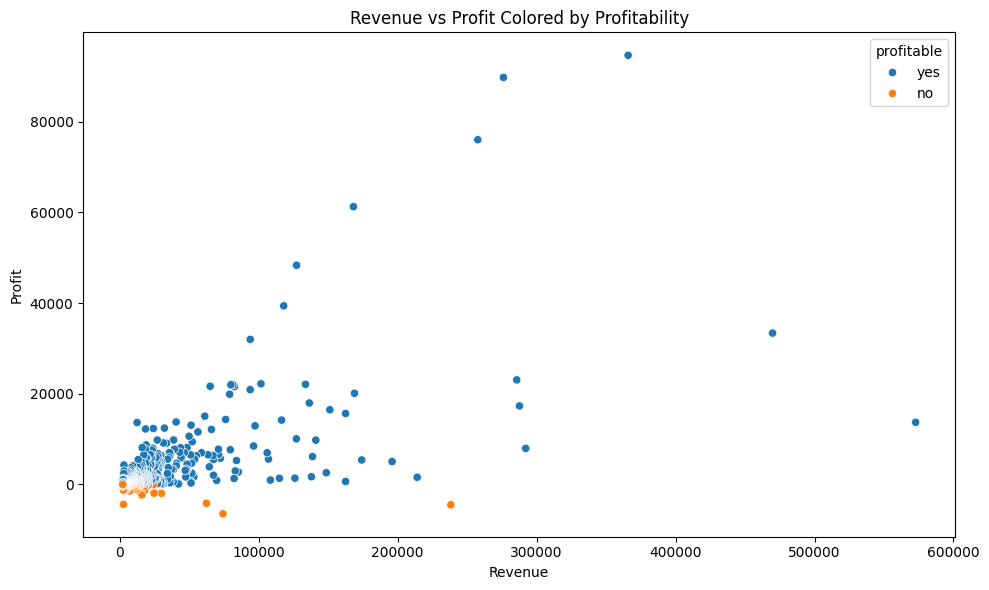

In [43]:
#  a scatter plot of revenue vs profit coloured by whether the company is profitable
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=fortune_df, x='revenue', y='profit', hue='profitable', ax=ax)
ax.set_title('Revenue vs Profit Colored by Profitability')
ax.set_xlabel('Revenue')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.show()


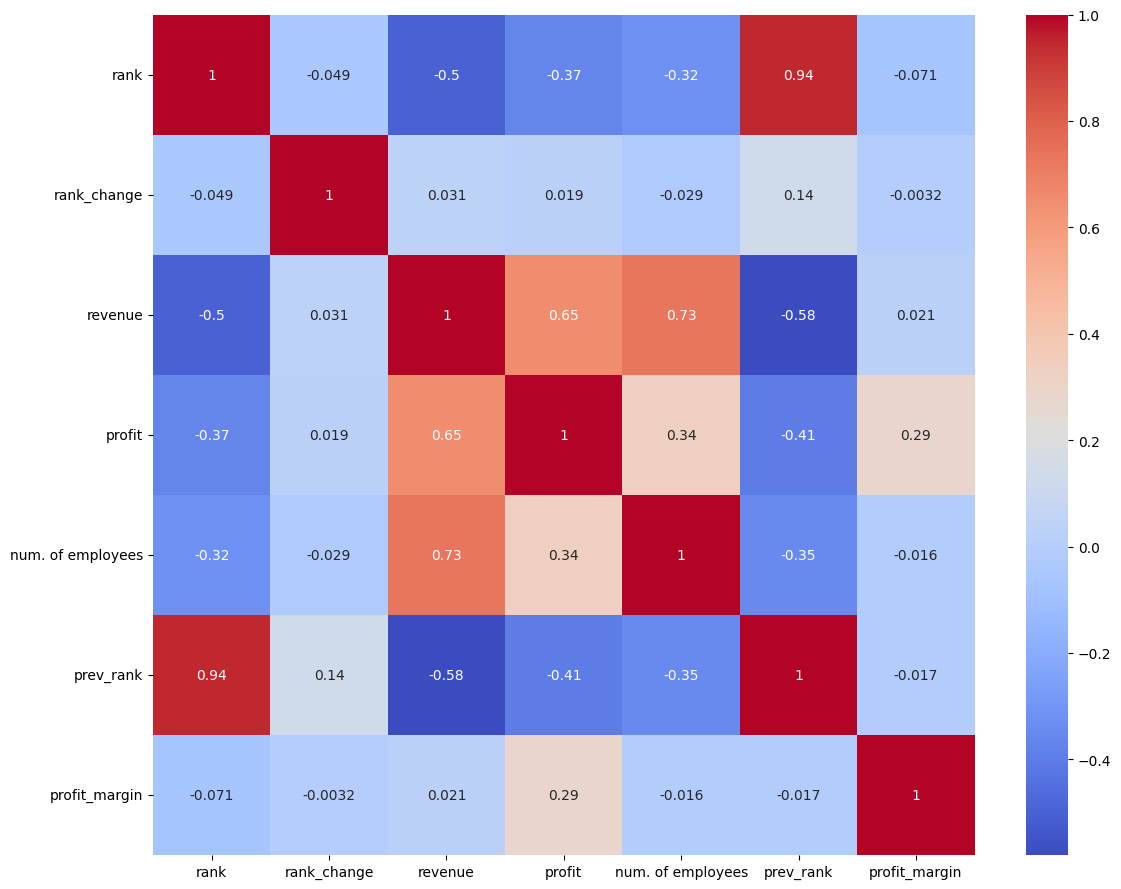

In [44]:
#  a correlation heatmap of all numeric columns with annotations
numeric_cols = fortune_df.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    cmap = 'coolwarm',
    annot = True,
    ax = ax
)

plt.tight_layout()
plt.show()

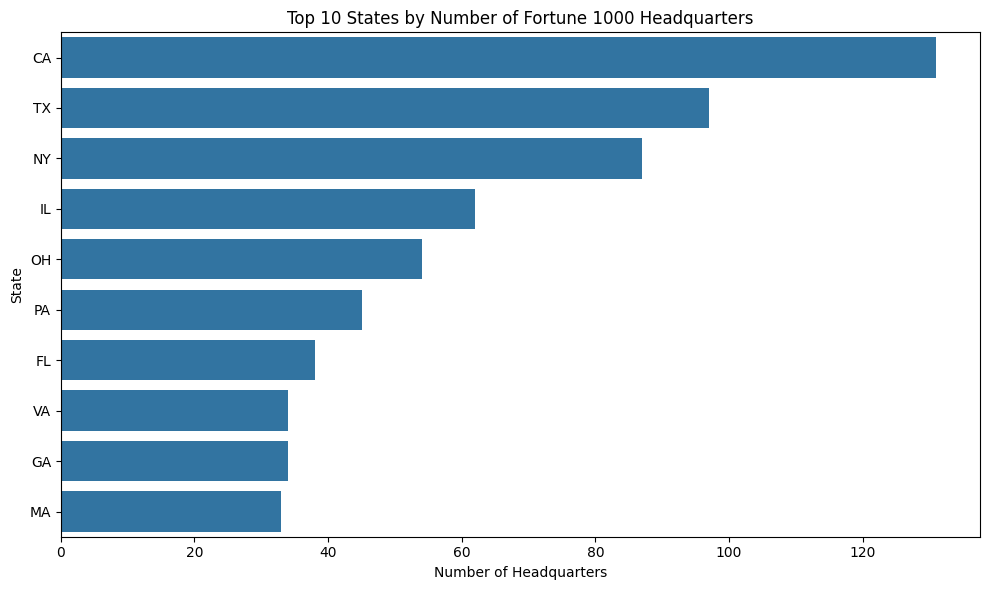

In [46]:
# a horizontal bar chart of the top 10 states by number of Fortune 500 headquarters
fig, ax = plt.subplots(figsize=(10, 6))
top_10_states = fortune_df["state"].value_counts().head(10)
sns.barplot(x=top_10_states.values, y=top_10_states.index, ax=ax)
ax.set_title('Top 10 States by Number of Fortune 1000 Headquarters')
ax.set_xlabel('Number of Headquarters')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

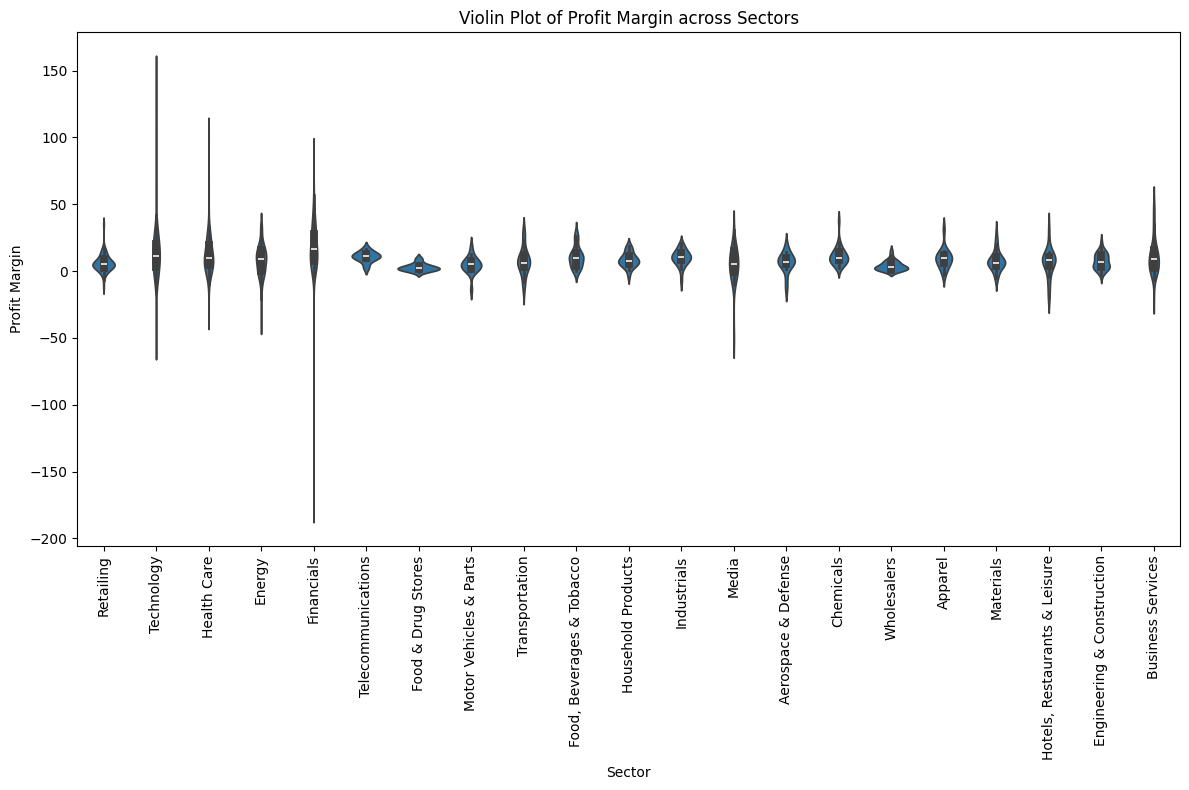

In [51]:
# a violinplot comparing profit_margin across sectors
fig, ax = plt.subplots(figsize=(12, 8))
sns.violinplot(x='sector', y='profit_margin', data=fortune_df, ax=ax)
ax.set_title('Violin Plot of Profit Margin across Sectors')
ax.set_xlabel('Sector') 
ax.set_ylabel('Profit Margin')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [50]:
fortune_df["sector"].nunique()

21

In [54]:
# Detect outliers in revenue using the IQR method. 
# Flag the outlier companies by name on the scatter plot. 
# Write a markdown cell interpreting what the outliers represent in business terms.
Q1 = fortune_df['revenue'].quantile(0.25)
Q3 = fortune_df['revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = fortune_df[(fortune_df['revenue'] < lower_bound) | (fortune_df['revenue'] > upper_bound)]
print("Outlier Companies based on Revenue:")   
print(outliers[['company', 'revenue']])



Outlier Companies based on Revenue:
                         company   revenue
0                        Walmart  572754.0
1                         Amazon  469822.0
2                          Apple  365817.0
3                     CVS Health  292111.0
4             UnitedHealth Group  287597.0
..                           ...       ...
106                     Qualcomm   33566.0
107        Capital One Financial   32033.0
108                    TD Synnex   31614.2
109  Philip Morris International   31405.0
110          World Fuel Services   31337.0

[111 rows x 2 columns]


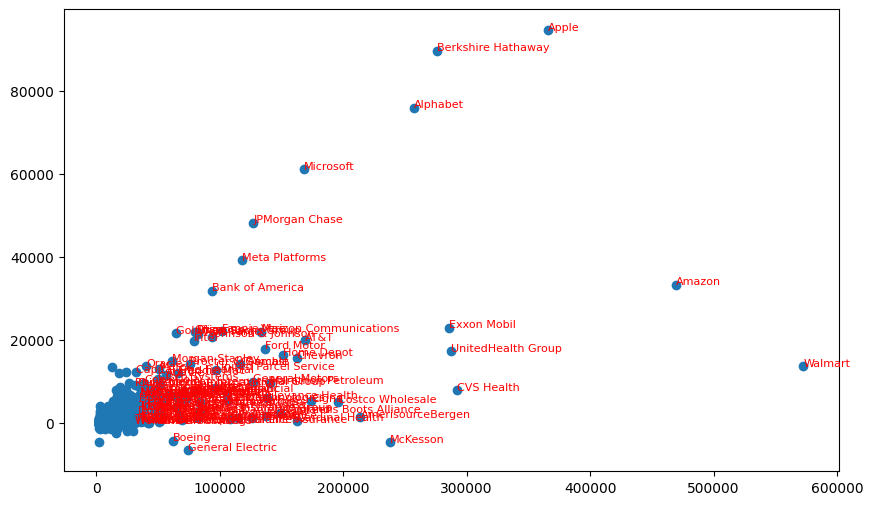

In [56]:
# Flag the outlier companies by name on the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

# plot all companies first
ax.scatter(fortune_df['revenue'], fortune_df['profit'])

# then label only the outlier companies by name
for _, row in outliers.iterrows():
    ax.annotate(row['company'],          # company name as label
                xy=(row['revenue'],      # x position
                    row['profit']),      # y position
                fontsize=8,
                color='red')

The revenue outliers represent the dominant giants of the 
Fortune 1000 list  companies like Walmart, Amazon, Apple, 
and ExxonMobil whose revenues are so large they sit far 
beyond the typical range.

These companies are not errors in the data  they are 
genuinely exceptional businesses operating at a scale 
that the majority of Fortune 1000 companies cannot match.

Their presence pulls the mean revenue significantly higher
than the median  which is why median is a better measure
of the typical Fortune 1000 company revenue than the mean.

From a machine learning perspective these outliers can 
skew model training  so depending on the objective they
may need to be treated separately or the revenue column
may need log transformation to reduce their influence.

## Summary of Findings

This analysis explored the Fortune 500 dataset to uncover 
patterns in revenue, profit, sector performance, and 
geographic distribution. Here are the five most important 
findings:

### Finding 1 — Revenue is Dominated by a Few Giants
...

### Finding 2 — Technology is the Most Profitable Sector
...

### Finding 3 — Most Companies Operate on Thin Margins
...

### Finding 4 — California, New York and Texas Lead in HQ Count
...

### Finding 5 — Profitability Follows Predictable Patterns
...

## Conclusion
These findings suggest that while the Fortune 500 represents 
Americas largest companies, success is far from uniform. 
A small number of giants drive outsized results while the 
majority operate modestly  creating opportunities for 
data driven decision making in investment and strategy.